<a href="https://colab.research.google.com/github/JazzyGis/MITgcm_GoA/blob/main/pco2_mooring_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ocean Station P CO2 moooring data analysis
### by J. Gistren and T. Ito, Spring 2026
- Download the raw data in .csv format
- Import into pandas dataframe
- Concatenate the raw data from 2008 to present into a single xarray dataset and save it as netCDF file
- Visualize the dataset

In [10]:
pip install PyCO2SYS

In [11]:
# import libraries first
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from dateutil.parser import parse
import PyCO2SYS as pyco2

In [12]:
df = pd.read_csv('OSP_2008_to_2025.csv')

In [13]:
#flag values filter
mask = (df['CO2 SW QF'] == 2) & (df['CO2 Air QF'] == 2)
df = df[mask]


In [14]:
# clean up the data before converting to xarray dataset
old_columns = df.columns
new_columns = [column.replace('/', 'Per') for column in list(df.columns)]  #issues with slash
merge_df = df.rename(columns=dict(zip(old_columns, new_columns)))
ds = merge_df.to_xarray()

In [15]:
# reformat the time variable in python datetime
date = ds['Date'].to_numpy()
time = ds['Time'].to_numpy()
N=np.size(date)
newtime=np.zeros(N,dtype='datetime64[ns]')
for n in range(N):
  newtime[n]=parse(date[n]+' '+time[n])

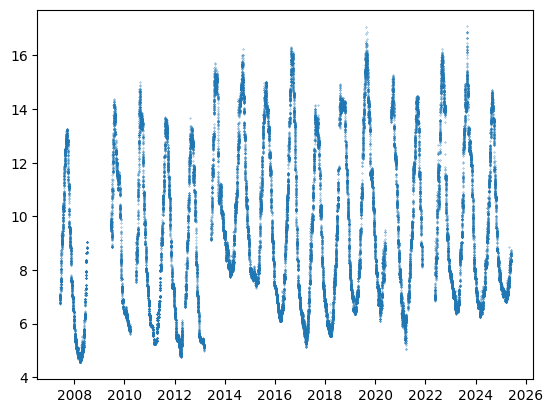

In [16]:
# have a quick look at the raw data
sst = ds['SST (C)'].to_numpy()
plt.plot(newtime,sst,'.',markersize=.5)

In [17]:
# extract the names of all variables
vars=list(ds.keys())
vars

['Unnamed: 0',
 'Mooring Name',
 'Latitude',
 'Longitude',
 'Date',
 'Time',
 'xCO2 SW (wet) (umolPermol)',
 'CO2 SW QF',
 'H2O SW (mmolPermol)',
 'xCO2 Air (wet) (umolPermol)',
 'CO2 Air QF',
 'H2O Air (mmolPermol)',
 'Licor Atm Pressure (hPa)',
 'Licor Temp (C)',
 'MAPCO2 %O2',
 'SST (C)',
 'Salinity',
 'xCO2 SW (dry) (umolPermol)',
 'xCO2 Air (dry) (umolPermol)',
 'fCO2 SW (sat) (uatm)',
 'fCO2 Air (sat) (uatm)',
 'dfCO2',
 'pCO2 SW (sat) (uatm)',
 'pCO2 Air (sat) (uatm)',
 'dpCO2',
 'pH (total scale)',
 'pH QF',
 'CHL (ugPerl)',
 'CHL QF',
 'NTU (NTU)',
 'NTU QF',
 'DOXY (umolPerkg)',
 'DOXY QF',
 'Licor Atm Pressure  (hPa)',
 'CHL',
 'NTU',
 'DOXY']

In [18]:
# redefine the dataset using python datetime and time as the dimension
varname=vars[0]
da = xr.DataArray(data=ds[varname],name=varname,\
                  dims=['time'],coords={'time':newtime})
ds_new = da.to_dataset()
#
for varname in vars[1:]:
  da = xr.DataArray(data=ds[varname],name=varname,\
                  dims=['time'],coords={'time':newtime})
  ds_new[varname]=da
#
ds_new = ds_new.sortby('time')

In [19]:
ds_new.time[0].dt.year.values

array(2007)

In [20]:
# save the raw data as a single netCDF file
ds_new.to_netcdf('rawdata_OSP_CO2_mooring.nc')

In [21]:
# resample the data for daily mean data
ds_daily = ds_new.resample(time='1D').mean()

In [22]:
# save the daily mean data as a separate netCDF file
ds_daily.to_netcdf('daily_OSP_CO2_mooring.nc')

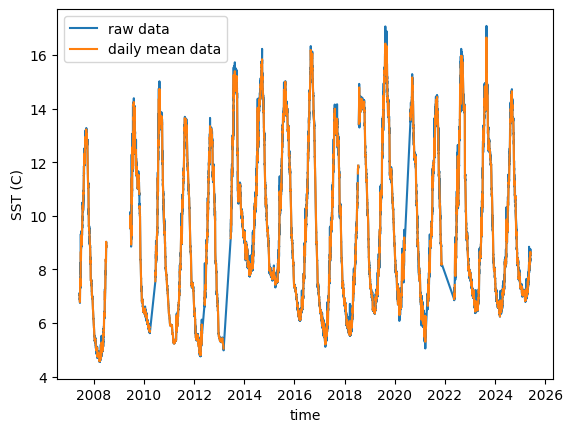

In [23]:
# compare the raw data and the daily mean data. Make sure they are similar
ds_new['SST (C)'].plot(label='raw data')
ds_daily['SST (C)'].plot(label='daily mean data')
plt.legend()
plt.show()

## Remaining task:
- Generate similar plots comparing raw data and daily data
- salinity
- xCO2_SW and xCO2_air
- pCO2_SW and pCO2_air
- fCO2_SW and fCO2_air

Go through and filter through flags = 2

In [24]:
# raw data is in ds_new
# daily data is in ds_daily

In [25]:
ds_daily

<xarray.Dataset> Size: 2MB
Dimensions:                      (time: 6567)
Coordinates:
  * time                         (time) datetime64[ns] 53kB 2007-06-08 ... 20...
Data variables: (12/34)
    Unnamed: 0                   (time) float64 53kB 12.5 29.5 ... 2.42e+03
    Latitude                     (time) float64 53kB 50.12 50.12 ... 50.05 50.05
    Longitude                    (time) float64 53kB -144.8 -144.8 ... -144.9
    xCO2 SW (wet) (umolPermol)   (time) float64 53kB 371.8 376.1 ... 407.3 403.5
    CO2 SW QF                    (time) float64 53kB 2.0 2.0 2.0 ... 2.0 2.0 2.0
    H2O SW (mmolPermol)          (time) float64 53kB 1.887 2.274 ... 1.799 1.833
    ...                           ...
    DOXY (umolPerkg)             (time) float64 53kB nan nan nan ... nan nan nan
    DOXY QF                      (time) float64 53kB nan nan nan ... 4.0 4.75
    Licor Atm Pressure  (hPa)    (time) float64 53kB 1.008e+03 995.2 ... nan nan
    CHL                          (time) float64 53kB nan nan nan ... 0.999 1.123
    NTU                          (time) float64 53kB nan nan ... 0.6617 0.7272
    DOXY                         (time) float64 53kB nan nan nan ... nan nan nan

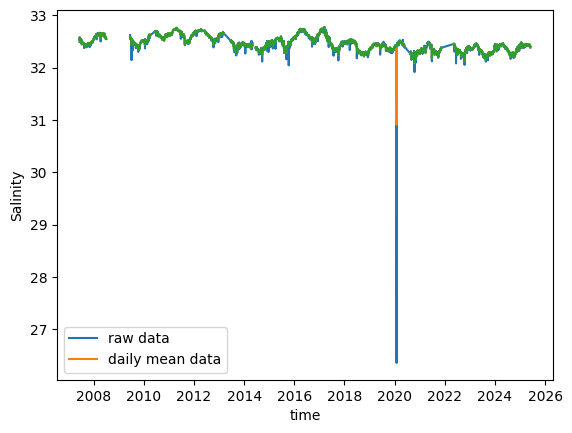

In [26]:
#salinity raw and daily
ds_new['Salinity'].plot(label='raw data')
ds_daily['Salinity'].plot(label='daily mean data')
#
sss = ds_daily['Salinity'].to_numpy()
mu_sss = np.nanmean(sss)
std_sss= np.nanstd(sss)
sss_QF = np.where(sss<(mu_sss-3*std_sss),4,2)
isgoodS = sss_QF == 2
time=ds_daily.time.to_numpy()
plt.plot(time[isgoodS],sss[isgoodS])
plt.legend()
plt.show()
#
# append new Salinity flag to the dataset
ds_daily['Salinity_QF']=xr.DataArray(data=sss_QF,dims=['time'],coords={'time':time})


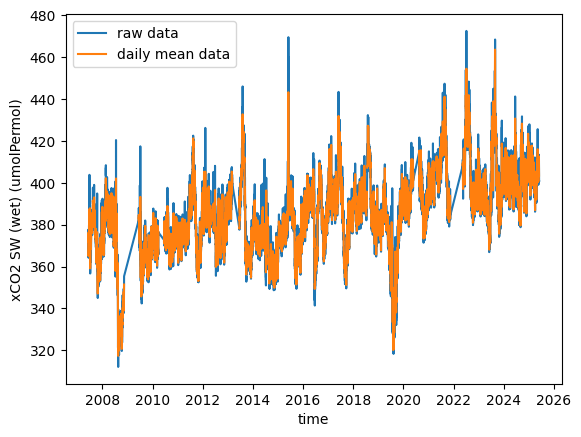

In [27]:
#xCO2_SW wet raw and daily
ds_new['xCO2 SW (wet) (umolPermol)'].plot(label='raw data')
ds_daily['xCO2 SW (wet) (umolPermol)'].plot(label='daily mean data')
plt.legend()
plt.show()

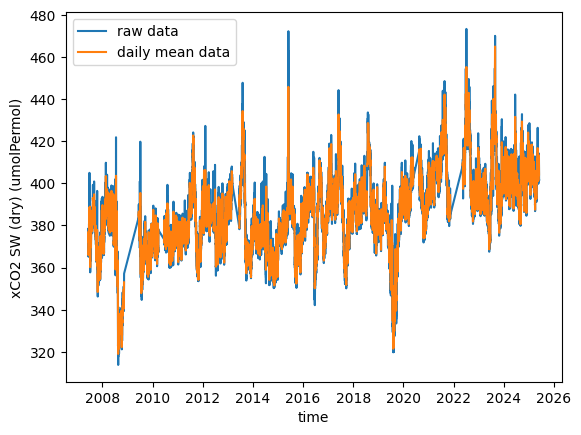

In [28]:
#xCO2_SW dry raw and daily
ds_new['xCO2 SW (dry) (umolPermol)'].plot(label='raw data')
ds_daily['xCO2 SW (dry) (umolPermol)'].plot(label='daily mean data')
plt.legend()
plt.show()

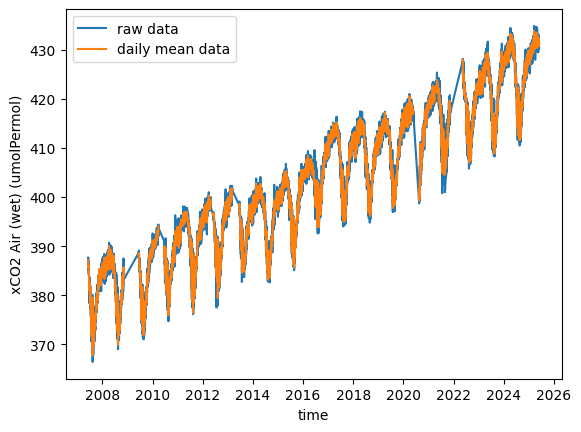

In [29]:
#xCO2_Air wet
ds_new['xCO2 Air (wet) (umolPermol)'].plot(label='raw data')
ds_daily['xCO2 Air (wet) (umolPermol)'].plot(label='daily mean data')
plt.legend()
plt.show()

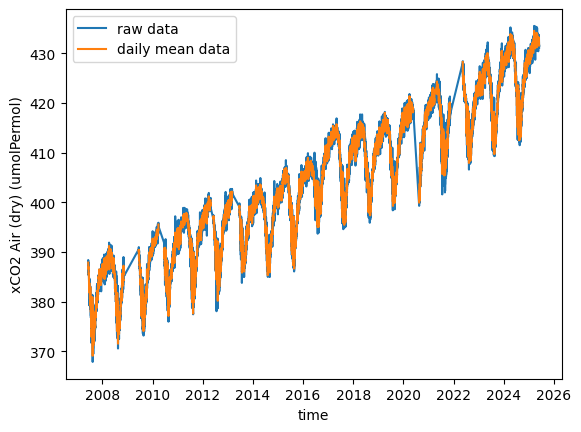

In [30]:
#xCO2_Air dry
ds_new['xCO2 Air (dry) (umolPermol)'].plot(label='raw data')
ds_daily['xCO2 Air (dry) (umolPermol)'].plot(label='daily mean data')
plt.legend()
plt.show()

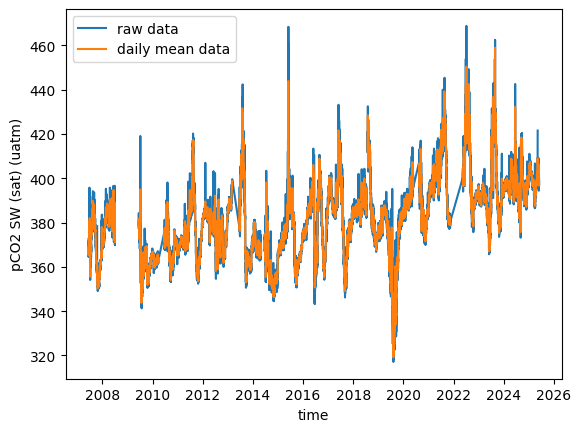

In [31]:
pco2wet = ds['pCO2 SW (sat) (uatm)'].to_numpy()
#plt.plot(newtime,xco2wet,'.',markersize=.5)
ds_new['pCO2 SW (sat) (uatm)'].plot(label='raw data')
ds_daily['pCO2 SW (sat) (uatm)'].plot(label='daily mean data')
plt.legend()
plt.show()

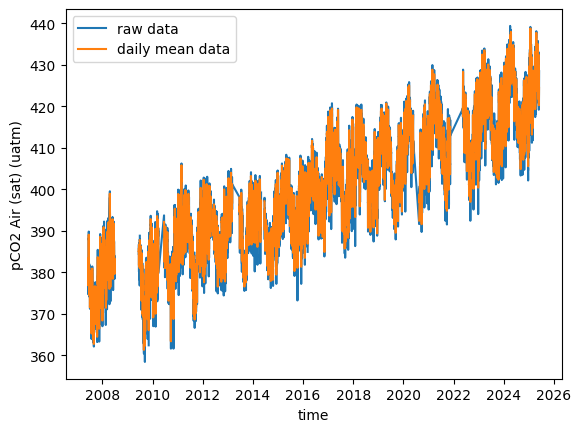

In [32]:
pco2dry = ds['pCO2 Air (sat) (uatm)'].to_numpy()
#plt.plot(newtime,pco2dry,'.',markersize=.5)
ds_new['pCO2 Air (sat) (uatm)'].plot(label='raw data')
ds_daily['pCO2 Air (sat) (uatm)'].plot(label='daily mean data')
plt.legend()
plt.show()

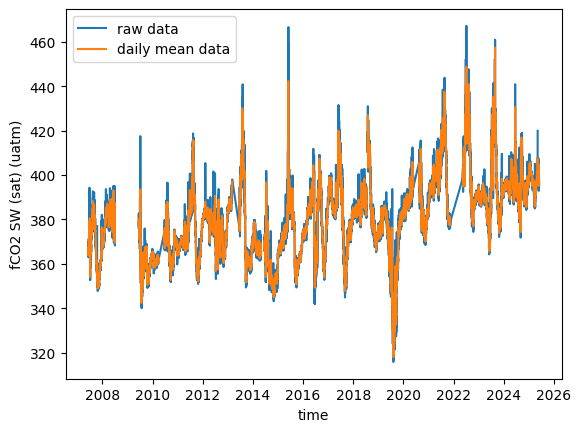

In [33]:
fco2wet = ds['fCO2 SW (sat) (uatm)'].to_numpy()
#plt.plot(newtime,fco2wet,'.',markersize=.5)
ds_new['fCO2 SW (sat) (uatm)'].plot(label='raw data')
ds_daily['fCO2 SW (sat) (uatm)'].plot(label='daily mean data')
plt.legend()
plt.show()

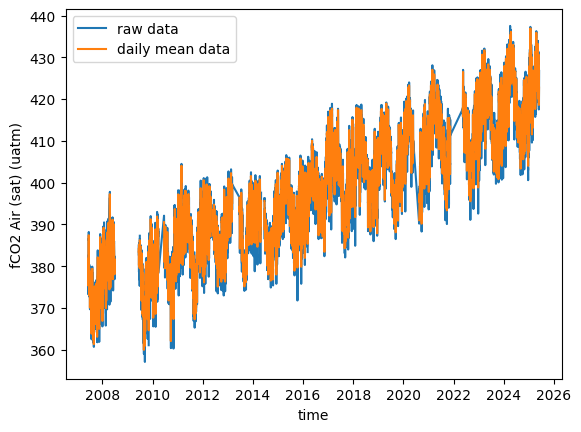

In [34]:
fco2dry = ds['fCO2 Air (sat) (uatm)'].to_numpy()
#plt.plot(newtime,fco2dry,'.',markersize=.5)
ds_new['fCO2 Air (sat) (uatm)'].plot(label='raw data')
ds_daily['fCO2 Air (sat) (uatm)'].plot(label='daily mean data')
plt.legend()
plt.show()

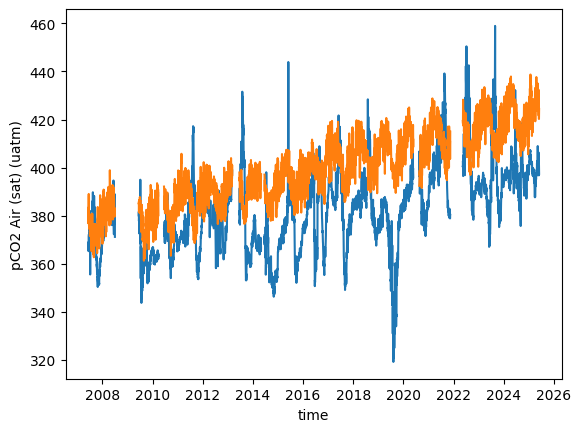

In [35]:
ds_daily['pCO2 SW (sat) (uatm)'].plot()
ds_daily['pCO2 Air (sat) (uatm)'].plot()

In [36]:
results = pyco2.sys(par1 = ds_daily['xCO2 SW (dry) (umolPermol)'], par1_type = 9,
                    par2 = ds_daily['pH (total scale)'], par2_type = 3,
                    salinity=ds_daily['Salinity'],
                    temperature=ds_daily['SST (C)'])

In [37]:
results

{'par1': array([372.52692308, 376.8875    , 372.7875    , ..., 413.3       ,
        407.9875    , 404.2       ]),
 'par1_type': array([9, 9, 9, ..., 9, 9, 9]),
 'par2': array([8.084125  , 8.082625  , 8.081375  , ..., 8.0240375 , 8.0249875 ,
        8.02807143]),
 'par2_type': array([3, 3, 3, ..., 3, 3, 3]),
 'alkalinity': array([2329.31510162, 2347.38820802, 2316.2089791 , ..., 2200.13768292,
        2177.29751554, 2174.98155552]),
 'dic': array([2161.53488574, 2179.29464697, 2151.05401993, ..., 2053.15378702,
        2030.65878991, 2027.86812519]),
 'opt_k_bisulfate': 1,
 'opt_k_carbonic': 10,
 'opt_k_fluoride': 1,
 'opt_total_borate': 1,
 'opt_gas_constant': 3,
 'opt_pH_scale': 1,
 'opt_buffers_mode': 1,
 'salinity': array([32.54    , 32.56525 , 32.5655  , ..., 32.406   , 32.39875 ,
        32.387625]),
 'temperature': array([7.05969231, 7.051875  , 6.9065    , ..., 8.60375   , 8.6555    ,
        8.563625  ]),
 'pressure': np.float64(0.0),
 'total_ammonia': np.float64(0.0),
 'total

In [38]:
dic=results['dic']

In [39]:
time=ds_daily['time']

In [40]:
dlnpco2=results['dlnpCO2_dT']

In [41]:
dlnpco2ave = np.nanmean(dlnpco2)
dlnpco2std = np.nanstd(dlnpco2)
print(dlnpco2ave,dlnpco2std)

0.043123294758218175 0.000760697219782742


In [42]:
pco2sw=ds_daily['pCO2 SW (sat) (uatm)'].to_numpy()
pco2sw_prime = pco2sw - np.nanmean(pco2sw)
SST = ds_daily['SST (C)'].to_numpy()
dpCO2T = pco2sw*dlnpco2ave*(SST-np.nanmean(SST))
dpCO2nonT = pco2sw_prime - dpCO2T

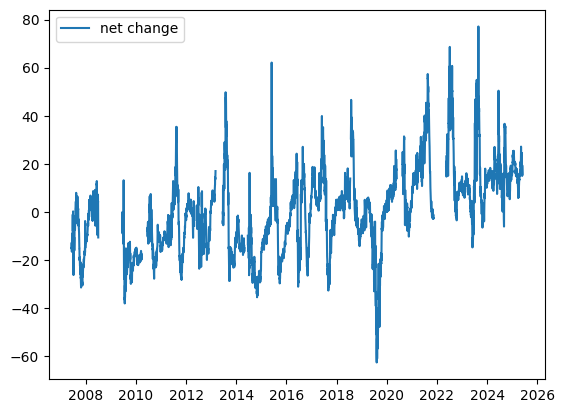

In [43]:
#plt.plot(time,dpCO2T,label='SST effect')
#plt.plot(time,dpCO2nonT,label='non-SST effect')
plt.plot(time,pco2sw_prime,label='net change')
plt.legend()

In [44]:
dpCO2T[0]

np.float64(-37.431628190343545)

In [45]:
#yearly averages
dpCO2T_da = xr.DataArray(data=dpCO2T, dims=['time'], coords={'time': ds_daily.time})
yearly_dpCO2T_mean = dpCO2T_da.groupby('time.year').mean()
yearly_dpCO2T = yearly_dpCO2T_mean.values.tolist()
#dpCO2nonT_da = xr.DataArray(data=dpCO2nonT, dims=['time'], coords={'time': ds_daily.time})
#yearly_dpCO2nonT_mean = dpCO2nonT_da.groupby('time.year').mean()
#yearly_dpCO2nonT = yearly_dpCO2nonT_mean.values.tolist()
pco2sw_prime_da = xr.DataArray(data=pco2sw_prime, dims=['time'], coords={'time': ds_daily.time})
yearly_pco2sw_prime_mean = pco2sw_prime_da.groupby('time.year').mean()
yearly_pco2sw_prime = yearly_pco2sw_prime_mean.values.tolist()

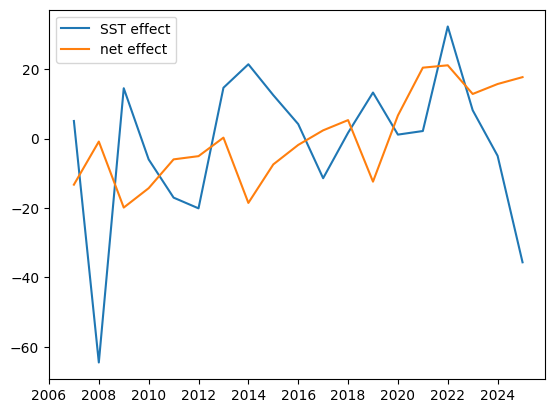

In [46]:
#plotting yearly averages
plt.plot(yearly_dpCO2T_mean.year, yearly_dpCO2T, label = 'SST effect')
#plt.plot(yearly_dpCO2nonT_mean.year, yearly_dpCO2T, label  = 'nonSST effect')  prints the same values
plt.plot(yearly_pco2sw_prime_mean.year, yearly_pco2sw_prime, label = 'net effect')
plt.xticks(np.arange(2006,2025,2))
plt.legend()

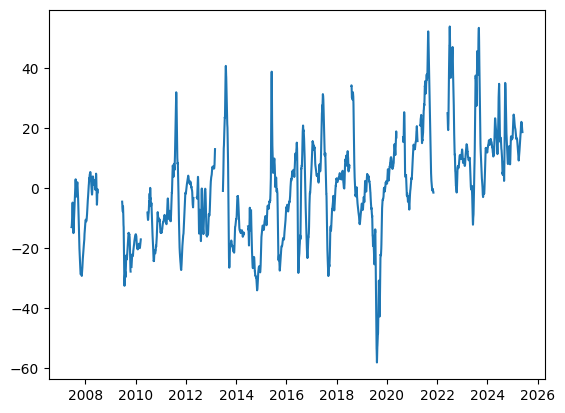

In [47]:
#moving window avg
dpCO2T_rolling_mean = np.convolve(pco2sw_prime, np.ones(12)/12, mode='valid')
plt.plot(time[6:-5],dpCO2T_rolling_mean)
#only a little bit less noise

In [48]:
#subtract monthly avg
dpCO2T_da = xr.DataArray(data=dpCO2T, dims=['time'], coords={'time': ds_daily.time})
dpCO2T_anom = dpCO2T_da.groupby('time.month') - dpCO2T_da.groupby('time.month').mean()  #compiles the 12 averages total or interannually?
dpCO2T_anom_prime = dpCO2T_anom.values.tolist()

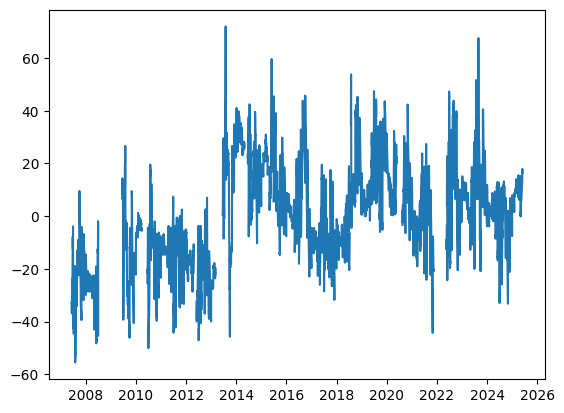

In [49]:
#plot the subtract monthly avg
plt.plot(time,dpCO2T_anom_prime, label = "pCO2 monthly anomalies")
#overlaying data

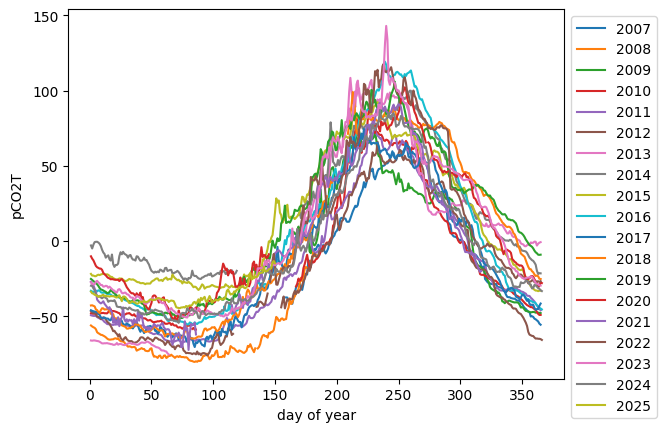

In [50]:
# yearly overlay
for year in np.unique(dpCO2T_da['time.year'].values):
    year_data = dpCO2T_da.where(dpCO2T_da['time.year'] == year, drop=True)
    plt.plot(year_data['time.dayofyear'], year_data.values, label = year)

plt.xlabel("day of year")
#plt.xticks(range(1,13), ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
plt.ylabel("pCO2T")
plt.legend(bbox_to_anchor=(1,1))

In [51]:
#next step is to plot the 2014, 2019, 2023 data with a reference to a standard year (ex. 2010)

In [52]:
#testing polyfit on rolling mean data

In [53]:
time1 = time[6:-5]
mask = ~np.isnan(time1) & ~np.isnan(dpCO2T_rolling_mean)
time1 = time1[mask]
dpCO2T_new_rolling_mean = dpCO2T_rolling_mean[mask]
coeffs = np.polyfit(time1.astype(float), dpCO2T_new_rolling_mean, 16)
p = np.poly1d(coeffs)
xfit = np.linspace(time1.astype(float).values.min(), time1.astype(float).values.max(), len(time1))
yfit = p(xfit)

/usr/local/lib/python3.12/dist-packages/numpy/lib/_polynomial_impl.py:656: RuntimeWarning: overflow encountered in multiply
  scale = NX.sqrt((lhs*lhs).sum(axis=0))
/tmp/ipykernel_1727/1635790889.py:5: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(time1.astype(float), dpCO2T_new_rolling_mean, 16)


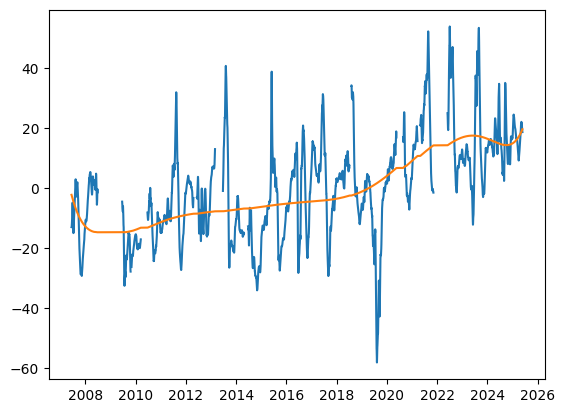

In [54]:
plt.plot(time[6:-5],dpCO2T_rolling_mean)  #repeat plot to overlay
plt.plot(time1,yfit)  #interpolation does not provide variance

In [55]:
#deseasonalize the dpCO2T
deseasonalized = dpCO2T_da.groupby('time.dayofyear') - dpCO2T_da.groupby('time.dayofyear').mean()
interpolated = deseasonalized.interpolate_na(dim='time', method='linear')

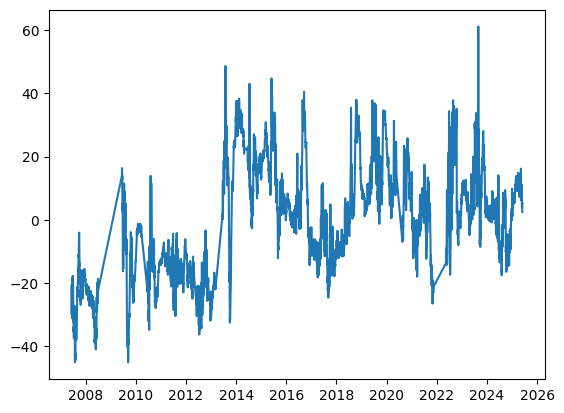

In [56]:
plt.plot((interpolated['time']), interpolated)

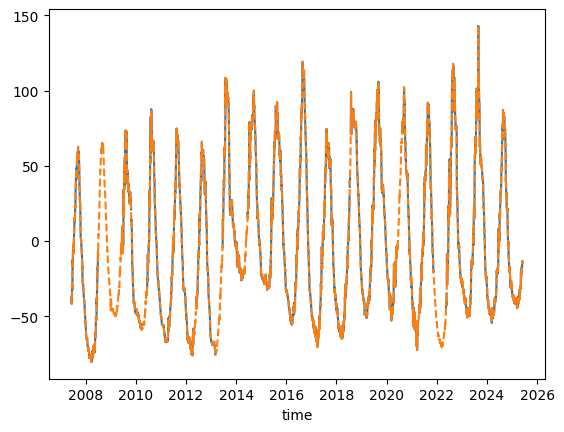

In [57]:
dpCO2T_da.plot()
temp = dpCO2T_da.groupby('time.dayofyear').mean().to_numpy()
temp1=interpolated.groupby('time.dayofyear')+dpCO2T_da.groupby('time.dayofyear').mean()
temp1.plot(linestyle='--')
#plt.plot(temp['time'],temp)
#plt.show()


In [57]:
#interpolate SSS
